## Параметры

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, root_scalar, least_squares
from scipy.special import roots_hermite
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------- Параметры (согласовано с Dynare) ----------
alpha   = 0.33
betta   = 0.95
delta   = 0.025
theta   = 1.25      # CRRA
psi     = 0.75      # disutility of labor exponent
phi     = 5.0
rho     = 0.7
sigma   = 0.2       # как в Dynare: sig_tfp = 0.2

def compute_steady_state():
    R = 1.0 / betta + delta - 1.0
    W = ((1.0 - alpha)**(1.0 - alpha) * alpha**alpha / R**alpha) ** (1.0 / (1.0 - alpha))
    K2L = (W / R) * alpha / (1.0 - alpha)
    C2L = K2L**alpha - delta * K2L
    L = ((W / phi) / C2L**theta) ** (1.0 / (psi + theta))
    K = K2L * L
    C = C2L * L
    Y = K**alpha * L**(1.0 - alpha)
    I = delta * K
    return K, L, C, Y, I, R, W

K_ss, L_ss, C_ss, Y_ss, I_ss, R_ss, W_ss = compute_steady_state()
print(f"SS: K={K_ss:.6f}, C={C_ss:.6f}, L={L_ss:.6f}, Y={Y_ss:.6f}, I={I_ss:.6f}")

# ---------- Границы ----------
K_min, K_max = 0.6 * K_ss, 1.4 * K_ss
std_z_uncond = sigma / np.sqrt(1.0 - rho**2)
z_min, z_max = -2.5 * std_z_uncond, 2.5 * std_z_uncond

n_K = 10
n_Z = 8
n_hermite = 7


SS: K=3.114430, C=0.654800, L=0.359216, Y=0.732661, I=0.077861


## 2. Узлы Чебышёва и базис

In [15]:
def chebyshev_nodes(n, a, b):
    x = np.cos((2.0*np.arange(1, n+1) - 1.0) * np.pi / (2.0*n))
    return 0.5*(a+b) + 0.5*(b-a)*x

def chebyshev_polynomials(x, deg, a, b):
    x = np.atleast_1d(x)
    y = 2.0 * (x - a) / (b - a) - 1.0
    y = np.clip(y, -1.0, 1.0)   # защита от выхода из диапазона
    T = np.zeros((len(x), deg))
    T[:, 0] = 1.0
    if deg > 1:
        T[:, 1] = y
    for k in range(2, deg):
        T[:, k] = 2.0 * y * T[:, k-1] - T[:, k-2]
    return T

K_nodes = np.sort(chebyshev_nodes(n_K, K_min, K_max))
z_nodes = np.sort(chebyshev_nodes(n_Z, z_min, z_max))

T_K = chebyshev_polynomials(K_nodes, n_K, K_min, K_max)
T_z = chebyshev_polynomials(z_nodes, n_Z, z_min, z_max)

## Функции модели

In [16]:
def labor_from_KC(K, C, z):
    if K <= 0 or C <= 1e-12:
        return np.nan
    tfp = np.exp(z)
    rhs = (1.0 - alpha) * tfp * (K ** alpha) / (phi * (C ** theta))
    if rhs <= 0:
        return np.nan
    L = rhs ** (1.0 / (psi + alpha))
    if not np.isfinite(L) or L <= 0:
        return np.nan
    return L

def production(K, L, z):
    return np.exp(z) * (K ** alpha) * (L ** (1.0 - alpha))

def rental_rate(K, L, z):
    Y = production(K, L, z)
    return alpha * Y / K

def wage(K, L, z):
    Y = production(K, L, z)
    return (1.0 - alpha) * Y / L

## 4. Начальное приближение

In [17]:
def solve_C_stationary_given_Kz(K, z):
    def res(C):
        L = labor_from_KC(K, C, z)
        if np.isnan(L):
            return 1e8
        Y = production(K, L, z)
        return Y - C - delta * K

    upper = max(2.5 * Y_ss, 2.5 * C_ss, 1.0)
    try:
        sol = root_scalar(res, bracket=[1e-8, upper], method='brentq')
        if sol.converged and np.isfinite(sol.root) and sol.root > 0:
            return sol.root
    except Exception:
        pass
    return C_ss

def numerical_elasticity():
    eps = 1e-4

    C_plus_k = solve_C_stationary_given_Kz(K_ss * (1.0 + eps), 0.0)
    C_minus_k = solve_C_stationary_given_Kz(K_ss * (1.0 - eps), 0.0)
    den_k = np.log(K_ss * (1.0 + eps)) - np.log(K_ss * (1.0 - eps))
    eta_c_k = (np.log(C_plus_k) - np.log(C_minus_k)) / den_k

    C_plus_z = solve_C_stationary_given_Kz(K_ss, +eps)
    C_minus_z = solve_C_stationary_given_Kz(K_ss, -eps)
    eta_c_z = (np.log(C_plus_z) - np.log(C_minus_z)) / (2.0 * eps)

    if (not np.isfinite(eta_c_k)) or abs(eta_c_k) > 10:
        eta_c_k = 0.25
    if (not np.isfinite(eta_c_z)) or abs(eta_c_z) > 10:
        eta_c_z = 1.00

    return eta_c_k, eta_c_z

eta_c_k, eta_c_z = numerical_elasticity()
print(f"eta_c_k = {eta_c_k:.6f}, eta_c_z = {eta_c_z:.6f}")

def initial_C(K, z):
    expo = eta_c_k * np.log(max(K, 1e-12) / K_ss) + eta_c_z * z
    expo = np.clip(expo, -50.0, 50.0)
    val = C_ss * np.exp(expo)
    return np.clip(val, 1e-8, 10.0 * C_ss)

C_init_grid = np.zeros((n_K, n_Z))
for i, K in enumerate(K_nodes):
    for j, z in enumerate(z_nodes):
        C_init_grid[i, j] = initial_C(K, z)

A = np.kron(T_z, T_K)
c_vec = C_init_grid.T.flatten()
theta_init_flat, _, _, _ = lstsq(A, c_vec, rcond=None)


eta_c_k = 0.256682, eta_c_z = 0.970751


## 5. Гаусс–Эрмит и правильное уравнение Эйлера

In [18]:
herm_nodes, herm_weights = roots_hermite(n_hermite)

def gh_expectation(func, z_current):
    mean = rho * z_current
    std = sigma
    z_next_vals = mean + np.sqrt(2.0) * std * herm_nodes
    weights = herm_weights / np.sqrt(np.pi)
    vals = np.array([func(z_next) for z_next in z_next_vals])
    return np.sum(weights * vals)

## 6. Аппроксимация политики C(K,z)

In [19]:
def C_from_theta(K, z, theta_mat):
    K_eval = np.clip(K, K_min, K_max)
    z_eval = np.clip(z, z_min, z_max)

    T_K_pt = chebyshev_polynomials(np.array([K_eval]), n_K, K_min, K_max).flatten()
    T_z_pt = chebyshev_polynomials(np.array([z_eval]), n_Z, z_min, z_max).flatten()

    C = T_K_pt @ theta_mat @ T_z_pt
    return max(C, 1e-8)

## 7. Исправленная невязка Эйлера

In [20]:
def euler_residuals(theta_flat, K_grid_1d, z_grid_1d, penalty=1e4, debug=False):
    theta_mat = theta_flat.reshape((n_K, n_Z))
    residuals = []

    for i, K in enumerate(K_grid_1d):
        for j, z in enumerate(z_grid_1d):
            C = C_from_theta(K, z, theta_mat)
            L = labor_from_KC(K, C, z)

            if np.isnan(L) or L <= 0:
                residuals.append(penalty)
                continue

            Y = production(K, L, z)
            I = Y - C
            K_next_raw = (1.0 - delta) * K + I

            if (not np.isfinite(K_next_raw)) or (K_next_raw <= 1e-10):
                residuals.append(penalty)
                continue

            # Для устойчивости: ожидание на ограниченной сетке + штраф за выход
            K_next = np.clip(K_next_raw, K_min, K_max)
            out_dist = abs(K_next_raw - K_next) / max(K_ss, 1e-8)

            def integrand(z_next):
                C_next = C_from_theta(K_next, z_next, theta_mat)
                L_next = labor_from_KC(K_next, C_next, z_next)

                if np.isnan(L_next) or L_next <= 0:
                    return 0.0

                R_next = rental_rate(K_next, L_next, z_next)

                val = (C / C_next) ** theta * (R_next + 1.0 - delta)
                if not np.isfinite(val):
                    return 0.0
                return val

            rhs = betta * gh_expectation(integrand, z)
            resid = 1.0 - rhs
            residuals.append(resid + 100.0 * (out_dist ** 2))

            if debug and i == len(K_grid_1d)//2 and j == len(z_grid_1d)//2:
                print(f"K={K:.4f}, z={z:.4f}, C={C:.4f}, K_next_raw={K_next_raw:.4f}, resid={resid:.4e}")

    return np.array(residuals)


## 8. Оптимизация

In [21]:
print("Проверка начальной невязки...")
init_res = euler_residuals(theta_init_flat, K_nodes, z_nodes)
init_ssr = np.sum(init_res**2)
print(f"SSR initial = {init_ssr:.6e}")
print(f"Max abs residual initial = {np.max(np.abs(init_res)):.6e}")
print("Оптимизация коэффициентов (least_squares)...")
lsq_result = least_squares(
    lambda th: euler_residuals(th, K_nodes, z_nodes),
    theta_init_flat,
    method='lm',
    max_nfev=500,
    ftol=1e-8,
    xtol=1e-8,
    gtol=1e-8,
    verbose=0
)
theta_opt = lsq_result.x.reshape((n_K, n_Z))
final_res = euler_residuals(lsq_result.x, K_nodes, z_nodes)
final_ssr = np.sum(final_res**2)
print("Status:", lsq_result.message)
print(f"Final SSR = {final_ssr:.6e}")
print(f"Max abs residual = {np.max(np.abs(final_res)):.6e}")
print(f"Improvement ratio (final/init) = {final_ssr / max(init_ssr, 1e-12):.4f}")
_ = euler_residuals(lsq_result.x, K_nodes, z_nodes, debug=True)


Проверка начальной невязки...
SSR initial = 1.247483e+03
Max abs residual initial = 1.924606e+01
Оптимизация коэффициентов (least_squares)...
Status: The maximum number of function evaluations is exceeded.
Final SSR = 6.858406e-01
Max abs residual = 5.081760e-01
Improvement ratio (final/init) = 0.0005
K=3.3093, z=0.1366, C=0.8395, K_next_raw=3.1659, resid=-8.0225e-03


## 9. Визуализация функции политики

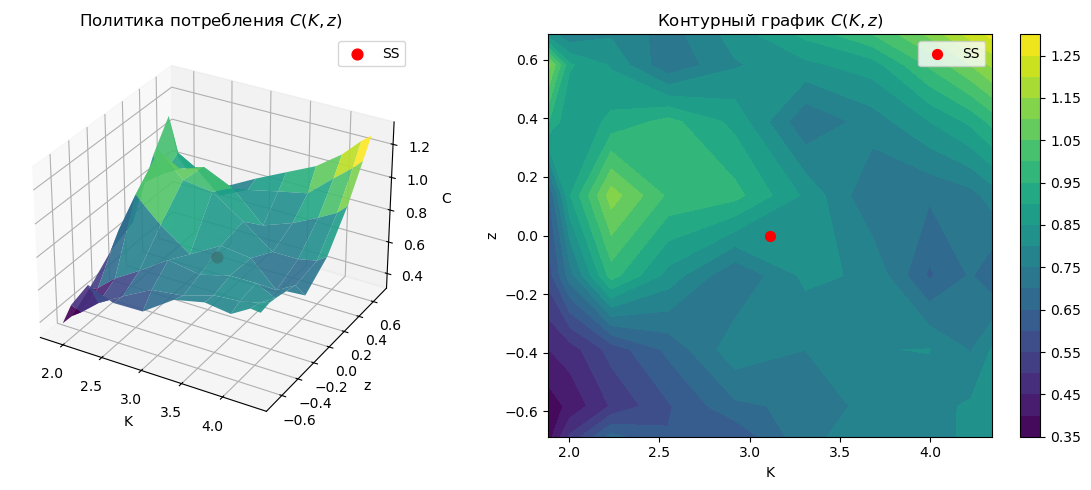

In [22]:
C_opt_grid = np.zeros((n_K, n_Z))

for i, K in enumerate(K_nodes):

    for j, z in enumerate(z_nodes):

        C_opt_grid[i, j] = C_from_theta(K, z, theta_opt)

K_mesh, z_mesh = np.meshgrid(K_nodes, z_nodes, indexing='ij')

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')

ax1.plot_surface(K_mesh, z_mesh, C_opt_grid, cmap='viridis', edgecolor='none', alpha=0.9)

ax1.scatter([K_ss], [0.0], [C_ss], color='red', s=60, label='SS')

ax1.set_xlabel('K')

ax1.set_ylabel('z')

ax1.set_zlabel('C')

ax1.set_title('Политика потребления $C(K,z)$')

ax1.legend()

ax2 = fig.add_subplot(122)

cont = ax2.contourf(K_mesh, z_mesh, C_opt_grid, levels=20, cmap='viridis')

ax2.scatter([K_ss], [0.0], color='red', s=50, label='SS')

ax2.set_xlabel('K')

ax2.set_ylabel('z')

ax2.set_title('Контурный график $C(K,z)$')

ax2.legend()

plt.colorbar(cont, ax=ax2)

plt.tight_layout()

plt.show()

## 10. Симуляция глобального стохастического решения

In [23]:
def simulate_global_irf(theta_mat, T_sim=40, shock_size=None):
    if shock_size is None:
        shock_size = sigma

    z_path = np.zeros(T_sim)
    z_path[0] = shock_size
    for t in range(1, T_sim):
        z_path[t] = rho * z_path[t-1]

    K_path = np.zeros(T_sim + 1)
    C_path = np.zeros(T_sim)
    L_path = np.zeros(T_sim)
    Y_path = np.zeros(T_sim)
    I_path = np.zeros(T_sim)
    clipped_steps = 0

    K_path[0] = K_ss

    for t in range(T_sim):
        K_t = K_path[t]
        z_t = z_path[t]

        C_t = C_from_theta(K_t, z_t, theta_mat)
        L_t = labor_from_KC(K_t, C_t, z_t)
        if np.isnan(L_t) or (not np.isfinite(L_t)) or L_t <= 0:
            L_t = L_ss

        Y_t = production(K_t, L_t, z_t)
        I_t = Y_t - C_t
        K_next_raw = (1.0 - delta) * K_t + I_t

        K_next = np.clip(K_next_raw, K_min, K_max)
        if abs(K_next - K_next_raw) > 1e-12:
            clipped_steps += 1

        C_path[t] = C_t
        L_path[t] = L_t
        Y_path[t] = Y_t
        I_path[t] = I_t
        K_path[t+1] = K_next

    if clipped_steps > 0:
        print(f"[diag] K_next clipped on {clipped_steps} / {T_sim} steps")

    return {
        'z': z_path,
        'K': K_path[:-1],
        'C': C_path,
        'L': L_path,
        'Y': Y_path,
        'I': I_path
    }

def pct_dev(x, x_ss):
    return 100.0 * (x / x_ss - 1.0)

sim_global = simulate_global_irf(theta_opt, T_sim=40, shock_size=sigma)


[diag] K_next clipped on 33 / 40 steps


## 11. Графики IRF со стационарным состоянием

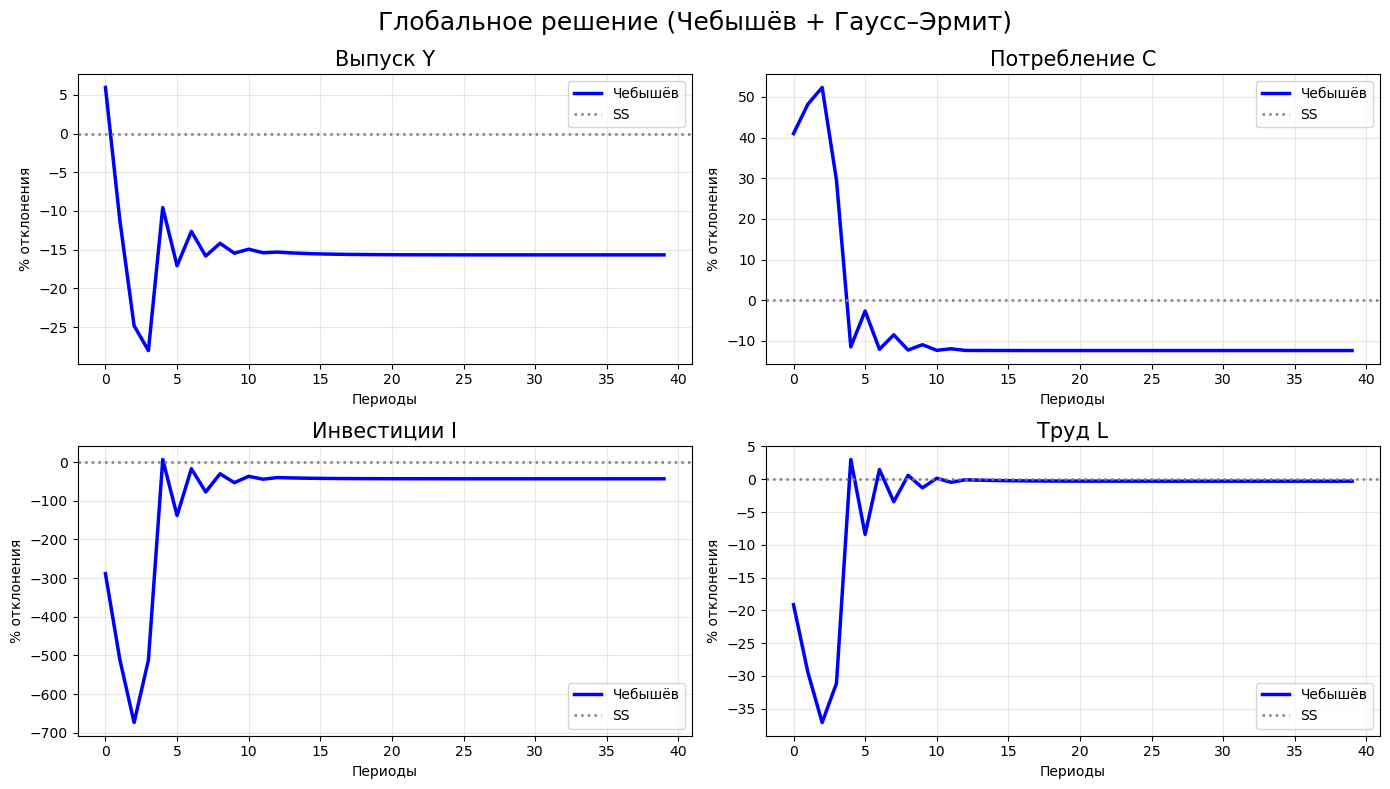

In [24]:
def plot_global_irf(sim):
    t = np.arange(len(sim['Y']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Глобальное решение (Чебышёв + Гаусс–Эрмит)', fontsize=18)

    series = [
        ('Y', Y_ss, 'Выпуск Y'),
        ('C', C_ss, 'Потребление C'),
        ('I', I_ss, 'Инвестиции I'),
        ('L', L_ss, 'Труд L'),
    ]

    for ax, (key, ss, title) in zip(axes.ravel(), series):
        ax.plot(t, pct_dev(sim[key], ss), color='blue', lw=2.5, label='Чебышёв')
        ax.axhline(0.0, color='gray', ls=':', lw=1.8, label='SS')
        ax.set_title(title, fontsize=15)
        ax.set_xlabel('Периоды')
        ax.set_ylabel('% отклонения')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_global_irf(sim_global)

## 12. Как сравнивать с Dynare

In [25]:
def plot_compare_irfs(sim_global, dynare_irfs, T=40):
    t = np.arange(T)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Сравнение: локальное решение (Dynare) vs глобальное решение (Чебышёв)', fontsize=18)

    comparison = [
        ('Y', Y_ss, dynare_irfs['Y'], 'Выпуск Y'),
        ('C', C_ss, dynare_irfs['C'], 'Потребление C'),
        ('I', I_ss, dynare_irfs['I'], 'Инвестиции I'),
        ('L', L_ss, dynare_irfs['L'], 'Труд L'),
    ]

    for ax, (key, ss, dyn, title) in zip(axes.ravel(), comparison):
        glob = pct_dev(sim_global[key][:T], ss)

        ax.plot(t, dyn[:T], 'r--', lw=2.5, label='Локальное')
        ax.plot(t, glob, 'b-', lw=2.2, label='Глобальное')
        ax.axhline(0.0, color='gray', ls=':', lw=1.6, label='SS')

        ax.set_title(title, fontsize=15)
        ax.set_xlabel('Периоды')
        ax.set_ylabel('% отклонения')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

Первые 5 значений Dynare (уровневые отклонения):
Y: [0.12611575 0.08706902 0.06260206 0.04364784 0.03078004]
C: [0.03660474 0.0331935  0.03057499 0.0278274  0.02553868]
I: [0.08951101 0.05387552 0.03202707 0.01582045 0.00524136]
L: [-0.02199756 -0.016408   -0.01275044 -0.01044373 -0.00939962]


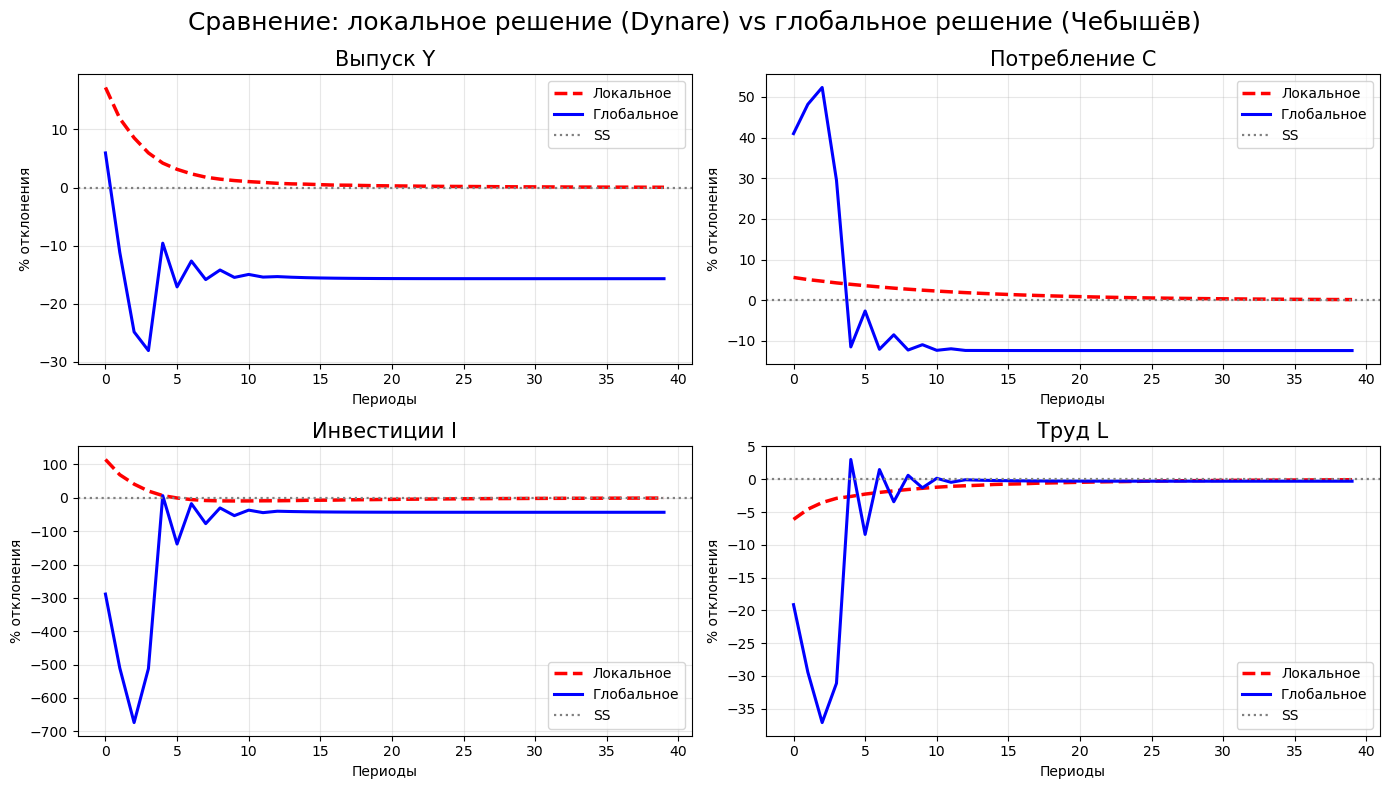

In [26]:
from scipy.io import loadmat
import numpy as np

mat = loadmat("dynare_irf.mat")

y_dyn = np.array(mat["Y_irf"]).flatten()
c_dyn = np.array(mat["C_irf"]).flatten()
i_dyn = np.array(mat["I_irf"]).flatten()
l_dyn = np.array(mat["L_irf"]).flatten()

print("Первые 5 значений Dynare (уровневые отклонения):")
print("Y:", y_dyn[:5])
print("C:", c_dyn[:5])
print("I:", i_dyn[:5])
print("L:", l_dyn[:5])

# Dynare дает отклонения в уровнях -> переводим в % от SS
dynare_irfs = {
    "Y": 100.0 * y_dyn / Y_ss,
    "C": 100.0 * c_dyn / C_ss,
    "I": 100.0 * i_dyn / I_ss,
    "L": 100.0 * l_dyn / L_ss,
}

T = min(40, len(y_dyn), len(sim_global["Y"]))
plot_compare_irfs(sim_global, dynare_irfs, T=T)
